# Explore the market-movers marts

Read the dbt outputs from DuckDB into pandas and chart them.

**Run order:** build the pipeline first (in a terminal, from the project root):

```bash
python scripts/seed_sample.py   # or: python ingest.py
dbt build --profiles-dir .
```

Then run the cells below. The connection is opened **read-only and per-query**,
so it won't fight dbt for the file lock - you can re-run `dbt build` in the
terminal any time the notebook isn't mid-query.

In [1]:
import os
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

# Absolute path to the database dbt built. Edit this if you move the project.
DB = os.path.expanduser("~/Downloads/market-movers-dbt/market.duckdb")
assert os.path.exists(DB), f"market.duckdb not found at {DB} - run `dbt build --profiles-dir .` first."

def q(sql: str) -> pd.DataFrame:
    """Short-lived, read-only query so we never hold the DuckDB write lock."""
    with duckdb.connect(DB, read_only=True) as con:
        return con.sql(sql).df()

print("Connected to", DB)

Connected to /Users/thiha.th/Downloads/market-movers-dbt/market.duckdb


## What's in the warehouse

In [2]:
q("""
    select table_schema, table_name
    from information_schema.tables
    order by table_schema, table_name
""")

,table_schema,table_name
0,main,fct_prices
1,main,int_daily_returns
2,main,mart_momentum
3,main,mart_movers
4,main,mart_portfolio_bias
5,main,mart_sector_overview
6,main,stg_prices
7,main,stg_watchlist
8,main,watchlist
9,raw,prices


## Sector overview

Your 20 names rolled up into medtech, crypto, and stocks - counts, average moves, breadth, and the best/worst name in each.

In [3]:
q("""
    select sector, n_names,
           round(avg_ret_1d*100, 2) as "avg 1D %",
           round(avg_ret_1m*100, 2) as "avg 1M %",
           round(pct_up_1d*100, 0)  as "% up today",
           top_ticker               as "top name",
           round(top_ret_1d*100, 2) as "top %",
           bottom_ticker            as "worst name",
           round(bottom_ret_1d*100, 2) as "worst %"
    from mart_sector_overview
""")

,sector,n_names,avg 1D %,avg 1M %,% up today,top name,top %,worst name,worst %
0,stocks,9,1.68,-2.86,89.0,TSLA,6.69,MSFT,-0.96
1,medtech,7,0.34,5.21,57.0,ISRG,1.60,BSX,-1.20
2,crypto,4,-1.40,1.15,0.0,SOL-USD,-0.92,AVAX-USD,-2.20


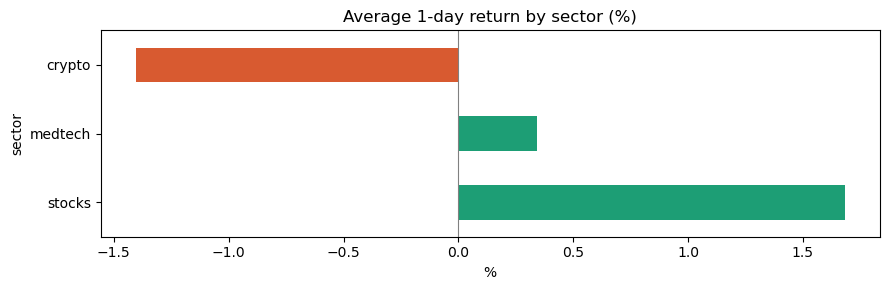

In [4]:
so = q("select sector, avg_ret_1d from mart_sector_overview").set_index("sector")["avg_ret_1d"].mul(100)
colors = ["#1D9E75" if v >= 0 else "#D85A30" for v in so]
ax = so.plot(kind="barh", figsize=(9, 3), color=colors)
ax.axvline(0, color="gray", linewidth=0.8)
ax.set_title("Average 1-day return by sector (%)")
ax.set_xlabel("%")
plt.tight_layout()
plt.show()

## Movers by sector

Every name, grouped by sector, sorted with the biggest 1-day gainer on top.

In [5]:
from IPython.display import display

movers = q("select ticker, name, sector, ret_1d, ret_5d, ret_1m from mart_movers")
for c in ("ret_1d", "ret_5d", "ret_1m"):
    movers[c] = (movers[c] * 100).round(2)
movers = movers.rename(columns={"ret_1d": "1D %", "ret_5d": "5D %", "ret_1m": "1M %"})

# each sector's names, best mover first
for sec in ["medtech", "crypto", "stocks"]:
    print(f"=== {sec.upper()} ===")
    display(
        movers[movers["sector"] == sec]
        .drop(columns="sector")
        .sort_values("1D %", ascending=False)
        .reset_index(drop=True)
    )

=== MEDTECH ===


,ticker,name,1D %,5D %,1M %
0,ISRG,Intuitive Surgical,1.60,6.95,6.27
1,DXCM,DexCom,1.59,3.19,-0.54
2,EW,Edwards Lifesciences,0.86,4.85,10.67
3,ABT,Abbott Laboratories,0.24,1.60,9.93
4,MDT,Medtronic,-0.16,2.57,6.56
5,SYK,Stryker,-0.55,-2.40,10.08
6,BSX,Boston Scientific,-1.20,0.84,-6.48


=== CRYPTO ===


,ticker,name,1D %,5D %,1M %
0,SOL-USD,Solana,-0.92,0.64,10.55
1,BTC-USD,Bitcoin,-1.21,2.82,-3.63
2,ETH-USD,Ethereum,-1.28,4.50,-0.88
3,AVAX-USD,Avalanche,-2.20,-0.34,-1.45


=== STOCKS ===


,ticker,name,1D %,5D %,1M %
0,TSLA,Tesla,6.69,10.55,-0.93
1,META,Meta Platforms,2.98,9.09,-3.64
2,GOOGL,Alphabet,1.82,8.62,2.08
3,QQQ,Invesco Nasdaq-100 ETF,1.43,2.31,-2.87
4,AAPL,Apple,1.31,10.18,0.77
5,SPY,SPDR S&P 500 ETF,0.87,3.06,-0.39
6,AMZN,Amazon,0.61,4.93,-2.34
7,NVDA,Nvidia,0.37,1.57,-8.94
8,MSFT,Microsoft,-0.96,3.69,-9.50


## Momentum & drawdown

In [6]:
q("""
    select ticker, name, trend_signal,
           round(drawdown_from_peak*100, 2) as drawdown_pct,
           round(daily_return_z, 2)          as last_move_z
    from mart_momentum
    order by trend_signal, drawdown_pct
""")

,ticker,name,trend_signal,drawdown_pct,last_move_z
0,BSX,Boston Scientific,downtrend,-54.79,-0.41
1,MSFT,Microsoft,downtrend,-20.01,-0.45
2,NVDA,Nvidia,downtrend,-17.05,0.15
3,DXCM,DexCom,downtrend,-7.43,0.66
4,AVAX-USD,Avalanche,uptrend,-54.06,-0.64
5,ETH-USD,Ethereum,uptrend,-47.10,-0.37
6,SOL-USD,Solana,uptrend,-44.70,-0.26
7,BTC-USD,Bitcoin,uptrend,-34.78,-0.47
8,ISRG,Intuitive Surgical,uptrend,-26.99,0.83
9,ABT,Abbott Laboratories,uptrend,-25.16,0.13


## Portfolio bias - holdings vs the Nasdaq\n\nHow correlated is your book to QQQ, and how deep is each holding's drawdown?

In [7]:
q("""
    select ticker, name,
           round(corr_to_nasdaq, 3)      as corr_to_nasdaq,
           overlapping_days,
           round(current_drawdown*100, 2) as current_drawdown_pct
    from mart_portfolio_bias
    order by corr_to_nasdaq desc
""")

,ticker,name,corr_to_nasdaq,overlapping_days,current_drawdown_pct
0,BTC-USD,Bitcoin,0.408,126,-34.78
1,AVAX-USD,Avalanche,0.342,126,-54.06


## Chart: normalised price history

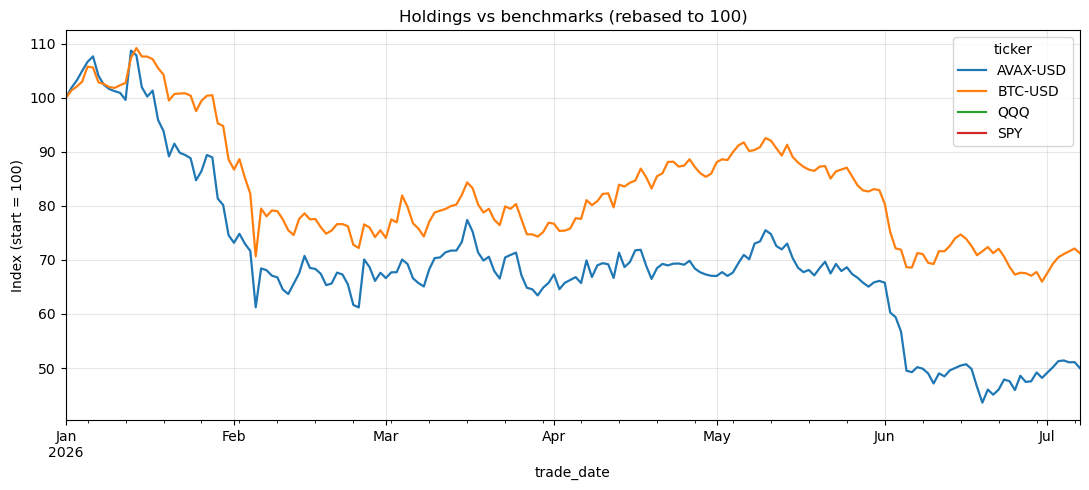

In [8]:
prices = q("""
    select f.ticker, f.trade_date, f.close_price
    from fct_prices f
    join stg_watchlist w using (ticker)
    where w.is_holding or w.is_benchmark
    order by f.trade_date
""")
prices["trade_date"] = pd.to_datetime(prices["trade_date"])

# rebase each series to 100 at its first observation for a fair comparison
wide = prices.pivot(index="trade_date", columns="ticker", values="close_price")
rebased = wide / wide.iloc[0] * 100

ax = rebased.plot(figsize=(11, 5), linewidth=1.6)
ax.set_title("Holdings vs benchmarks (rebased to 100)")
ax.set_ylabel("Index (start = 100)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Chart: drawdown of a single ticker

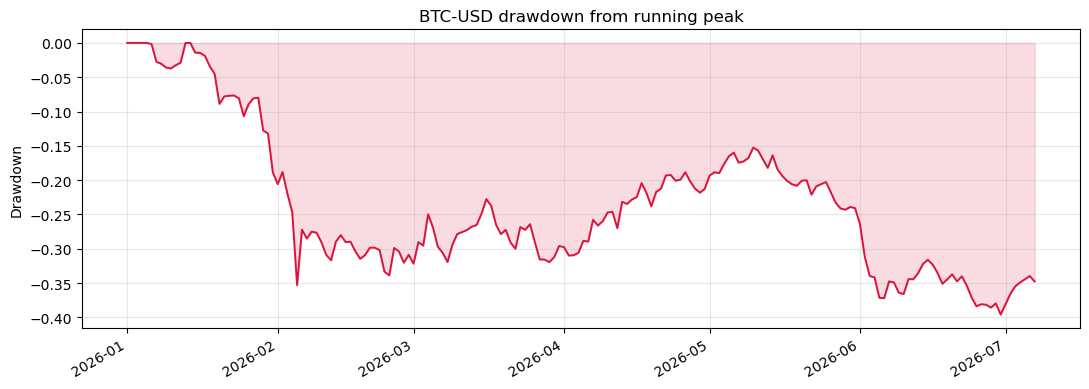

In [9]:
import matplotlib.dates as mdates

TICKER = "BTC-USD"   # change me

dd = q(f"""
    select trade_date, drawdown_from_peak
    from int_daily_returns
    where ticker = '{TICKER}'
    order by trade_date
""")
dd["trade_date"] = pd.to_datetime(dd["trade_date"])

# Convert dates to matplotlib floats so fill_between never has to mix
# datetime64 and float64 (newer numpy refuses that promotion).
x = mdates.date2num(dd["trade_date"])
y = dd["drawdown_from_peak"].to_numpy()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(x, y, color="crimson", linewidth=1.4)
ax.fill_between(x, y, 0.0, color="crimson", alpha=0.15)
ax.xaxis_date()
ax.set_title(f"{TICKER} drawdown from running peak")
ax.set_ylabel("Drawdown")
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Iterating

- **Re-run the pipeline** any time from a terminal: `dbt build --profiles-dir .`.
  Because `q()` opens read-only and closes immediately, you don't need to restart
  the kernel - just re-run the cells after the build finishes.
- If you ever see a **lock error**, a previous cell is holding a connection. Run
  `duckdb.connect` calls only through `q()` (which closes via the `with` block),
  or restart the kernel.
- To run dbt from inside the notebook instead of a terminal:
  `!cd .. && dbt build --profiles-dir .` (from a `notebooks/` subfolder).